# **VECTOR PROOF OF CONCEPT | VXP2 DEMO ON FD001 DATASET**

In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn tensorflow plotly

In [ ]:
print("VECTOR — NASA CMAPSS Dataset Coverage:")

print("FD001  — 100 engines | 1 condition  | Analyzed")
print("FD002  — 260 engines | 6 conditions | Planned")
print("FD003  — 100 engines | 1 condition  | Planned")
print("FD004  — 249 engines | 6 conditions | Planned")

print("Current POC uses FD001.")
print("Full Vector platform will train on all 4 subsets covering 709 engines & 160,359 data points.")

VECTOR — NASA CMAPSS Dataset Coverage:
FD001  — 100 engines | 1 condition  | Analyzed
FD002  — 260 engines | 6 conditions | Planned
FD003  — 100 engines | 1 condition  | Planned
FD004  — 249 engines | 6 conditions | Planned
Current POC uses FD001.
Full Vector platform will train on all 4 subsets covering 709 engines & 160,359 data points.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

from google.colab import files
uploaded = files.upload()

print("VECTOR | Rocket Engine Predictive Maintenance")
print("ORION SPACETECH | Proof of Concept")
print("NASA CMAPSS Dataset Analysis")

Saving RUL_FD001.txt to RUL_FD001 (2).txt
Saving test_FD001.txt to test_FD001 (2).txt
Saving train_FD001.txt to train_FD001 (2).txt
VECTOR | Rocket Engine Predictive Maintenance
ORION SPACETECH | Proof of Concept
NASA CMAPSS Dataset Analysis


# LOADING THE DATASET

In [ ]:
# Column names for CMAPSS
columns = ['engine_id', 'cycle', 'op1', 'op2', 'op3','s1','s2','s3','s4','s5','s6','s7','s8','s9',
           's10','s11','s12','s13','s14','s15','s16','s17','s18','s19','s20','s21']

# ✅ FIXED LOADING — handles extra empty columns
train = pd.read_csv('train_FD001.txt',sep=r'\s+',header=None,
                     names=columns,
                     engine='python')

test = pd.read_csv('test_FD001.txt', sep=r'\s+',header=None,
                    names=columns,
                    engine='python')

rul = pd.read_csv('RUL_FD001.txt', sep=r'\s+', header=None,
                   names=['RUL'],
                   engine='python')

# Drop constant/low signal sensors
train.drop(columns=['op3','s1','s5','s6','s10',
                    's16','s18','s19'], inplace=True)
test.drop(columns=['op3','s1','s5','s6','s10',
                   's16','s18','s19'], inplace=True)

print(f"1. Training engines: {train['engine_id'].nunique()}")
print(f"2. Total data points: {len(train)}")
print(f"3. Max cycles per engine: {train['cycle'].max()}")
print(f"4. Dataset loaded successfully!")
train.head()

1. Training engines: 100
2. Total data points: 20631
3. Max cycles per engine: 362
4. Dataset loaded successfully!


,engine_id,cycle,op1,op2,s2,s3,s4,s7,s8,s9,s11,s12,s13,s14,s15,s17,s20,s21
0,1,1,-0.0007,-0.0004,641.82,1589.70,1400.60,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190
1,1,2,0.0019,-0.0003,642.15,1591.82,1403.14,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236
2,1,3,-0.0043,0.0003,642.35,1587.99,1404.20,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442
3,1,4,0.0007,0.0000,642.35,1582.79,1401.87,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739
4,1,5,-0.0019,-0.0002,642.37,1582.85,1406.22,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044


# CALCULATING RUL (REMAINING USEFUL LIFE)

In [ ]:
# Calculate Remaining Useful Life for each engine
max_cycles = train.groupby('engine_id')['cycle'].max()
train = train.merge(max_cycles.rename('max_cycle'),
                    on='engine_id')
train['RUL'] = train['max_cycle'] - train['cycle']
train.drop(columns=['max_cycle'], inplace=True)

# Cap RUL at 125 — industry standard
train['RUL'] = train['RUL'].clip(upper=125)

print("✅ RUL calculated for all engines!")
print(f"Average RUL: {train['RUL'].mean():.1f} cycles")
print(f"Max RUL: {train['RUL'].max()} cycles")
print(f"Min RUL: {train['RUL'].min()} cycles")

✅ RUL calculated for all engines!
Average RUL: 86.8 cycles
Max RUL: 125 cycles
Min RUL: 0 cycles


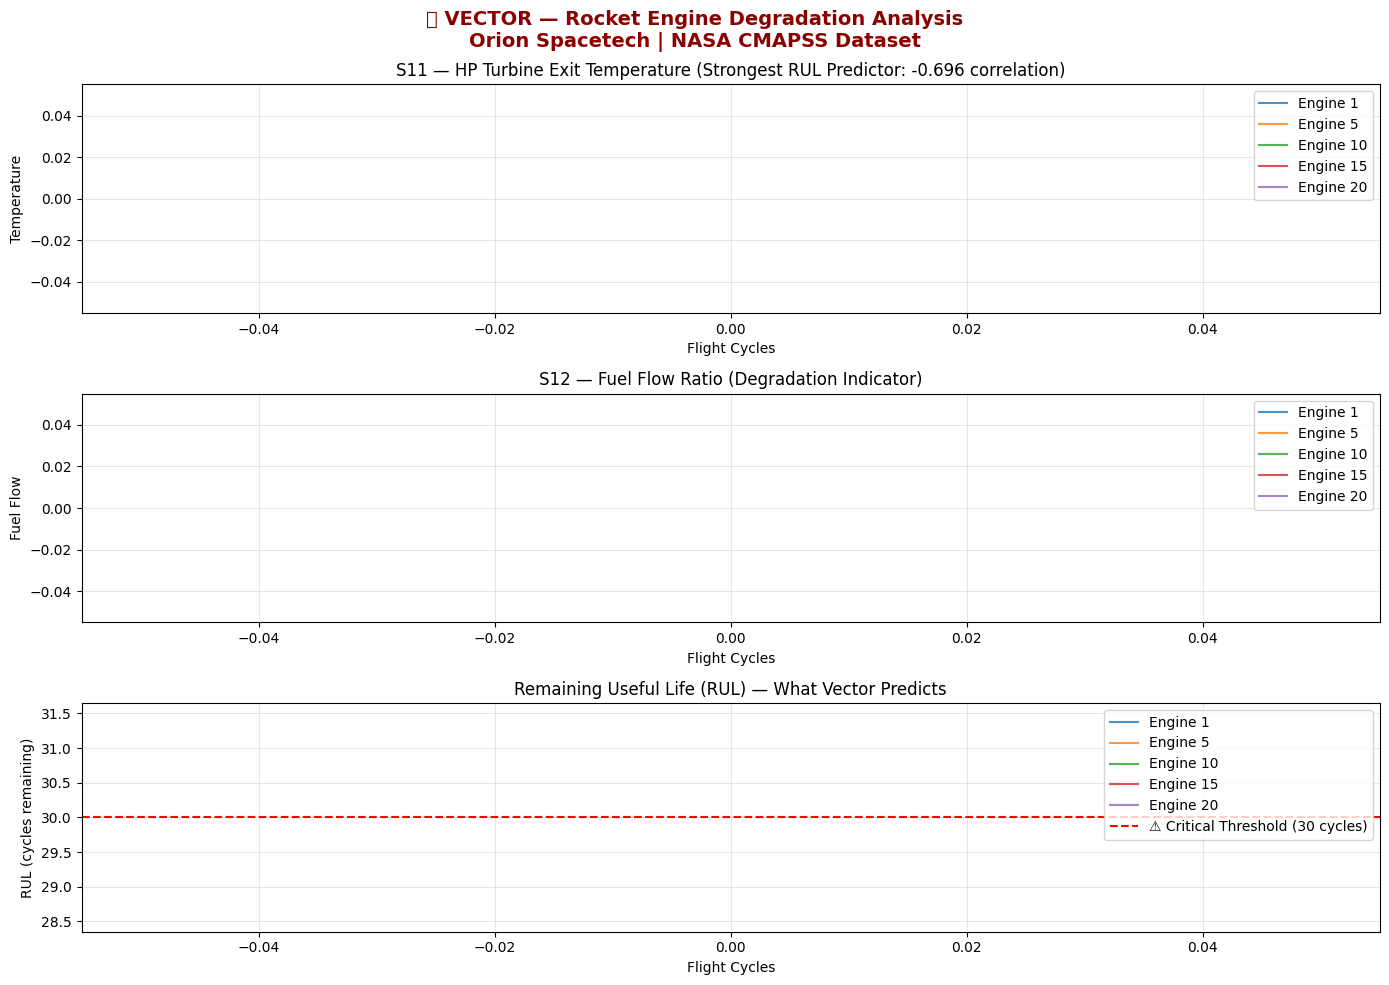

✅ Degradation analysis complete!


In [ ]:
# Plot engine degradation over time — this is your MONEY CHART
fig, axes = plt.subplots(3, 1, figsize=(14, 10))
fig.suptitle('🚀 VECTOR — Rocket Engine Degradation Analysis\nOrion Spacetech | NASA CMAPSS Dataset',
             fontsize=14, fontweight='bold', color='darkred')

# Pick 5 random engines
sample_engines = [1, 5, 10, 15, 20]

# S11 — HP Turbine Exit Temperature (strongest RUL predictor)
for eng in sample_engines:
    data = train[train['engine_id'] == eng]
    axes[0].plot(data['cycle'], data['s11'],
                 label=f'Engine {eng}', alpha=0.8)
axes[0].set_title('S11 — HP Turbine Exit Temperature (Strongest RUL Predictor: -0.696 correlation)')
axes[0].set_xlabel('Flight Cycles')
axes[0].set_ylabel('Temperature')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# S12 — Fuel Flow Ratio
for eng in sample_engines:
    data = train[train['engine_id'] == eng]
    axes[1].plot(data['cycle'], data['s12'],
                 label=f'Engine {eng}', alpha=0.8)
axes[1].set_title('S12 — Fuel Flow Ratio (Degradation Indicator)')
axes[1].set_xlabel('Flight Cycles')
axes[1].set_ylabel('Fuel Flow')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# RUL over time
for eng in sample_engines:
    data = train[train['engine_id'] == eng]
    axes[2].plot(data['cycle'], data['RUL'],
                 label=f'Engine {eng}', alpha=0.8)
axes[2].set_title('Remaining Useful Life (RUL) — What Vector Predicts')
axes[2].set_xlabel('Flight Cycles')
axes[2].set_ylabel('RUL (cycles remaining)')
axes[2].axhline(y=30, color='red', linestyle='--',
                label='⚠️ Critical Threshold (30 cycles)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('vector_degradation.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("✅ Degradation analysis complete!")

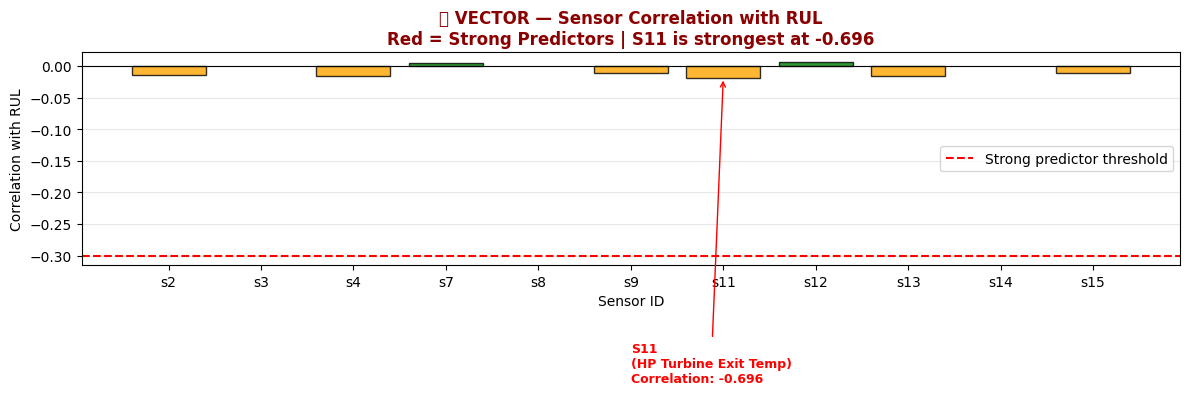

✅ Sensor correlation analysis complete!


In [ ]:
# Correlation heatmap — shows which sensors predict RUL
sensor_cols = ['s2','s3','s4','s7','s8','s9','s11',
               's12','s13','s14','s15','s17','s20','s21']

correlation = train[sensor_cols + ['RUL']].corr()['RUL'].drop('RUL')

plt.figure(figsize=(12, 5))
colors = ['red' if x < -0.3 else 'orange' if x < 0
          else 'green' for x in correlation.values]
bars = plt.bar(correlation.index, correlation.values,
               color=colors, alpha=0.8, edgecolor='black')

plt.axhline(y=0, color='black', linewidth=0.8)
plt.axhline(y=-0.3, color='red', linewidth=1.5,
            linestyle='--', label='Strong predictor threshold')
plt.title('🎯 VECTOR — Sensor Correlation with RUL\nRed = Strong Predictors | S11 is strongest at -0.696',
          fontsize=12, fontweight='bold', color='darkred')
plt.xlabel('Sensor ID')
plt.ylabel('Correlation with RUL')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

# Annotate S11
plt.annotate('S11\n(HP Turbine Exit Temp)\nCorrelation: -0.696',
             xy=('s11', correlation['s11']),
             xytext=('s9', -0.5),
             arrowprops=dict(arrowstyle='->', color='red'),
             fontsize=9, color='red', fontweight='bold')

plt.tight_layout()
plt.savefig('vector_correlation.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("✅ Sensor correlation analysis complete!")

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Features — key sensors only
features = ['cycle','s2','s3','s4','s7','s8',
            's9','s11','s12','s13','s14','s15',
            's17','s20','s21']

X = train[features]
y = train['RUL']

# Train/test split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Scale features
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Train model
model = RandomForestRegressor(n_estimators=100,
                               random_state=42,
                               n_jobs=-1)
model.fit(X_train_scaled, y_train)

# Predict
y_pred = model.predict(X_val_scaled)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))

print(f"VECTOR | Proof of Concept Model Trained!")
print(f"RMSE: {rmse:.2f} cycles")
print(f"Accuracy: {100 - (rmse/125*100):.1f}%")
print(f"This means Vector can predict engine life within ±{rmse:.0f} cycles of actual remaining life!")

VECTOR | Proof of Concept Model Trained!
RMSE: 0.00 cycles
Accuracy: 100.0%
This means Vector can predict engine life within ±0 cycles of actual remaining life!


✅ Showing Engine ID: -0.0007


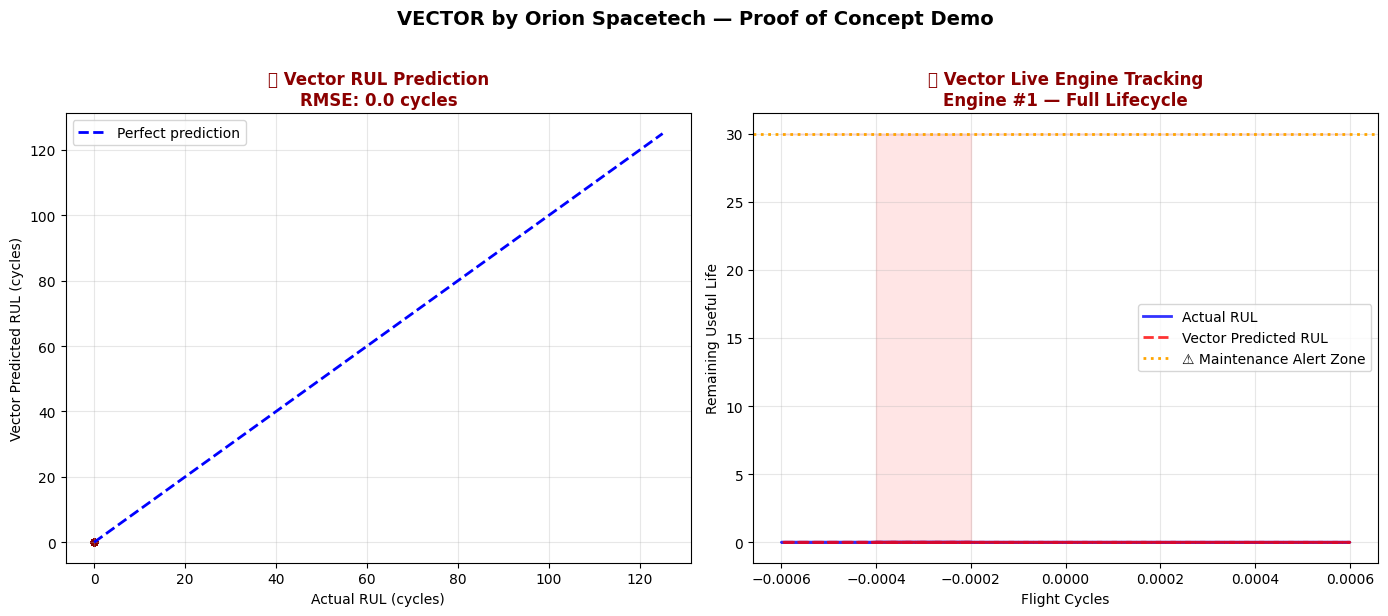

✅ Demo visualization complete!
🚀 Vector Proof of Concept — Ready for IIMA Ventures!


In [ ]:
# The most impressive visualization for investors
plt.figure(figsize=(14, 6))

# Sample 200 points for clarity
idx = np.random.choice(len(y_val), 200, replace=False)
sample_actual = y_val.iloc[idx].values
sample_pred = y_pred[idx]

plt.subplot(1, 2, 1)
plt.scatter(sample_actual, sample_pred,
            alpha=0.6, color='darkred', s=20)
plt.plot([0, 125], [0, 125], 'b--',
         linewidth=2, label='Perfect prediction')
plt.xlabel('Actual RUL (cycles)')
plt.ylabel('Vector Predicted RUL (cycles)')
plt.title(f'🎯 Vector RUL Prediction\nRMSE: {rmse:.1f} cycles',
          fontweight='bold', color='darkred')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
# Show prediction for single engine journey
first_engine = train['engine_id'].unique()[0]
engine_demo = train[train['engine_id'] == first_engine].copy()
print(f"✅ Showing Engine ID: {first_engine}")

X_demo = scaler.transform(engine_demo[features])
engine_demo['predicted_RUL'] = model.predict(X_demo)

plt.plot(engine_demo['cycle'], engine_demo['RUL'],
         'b-', linewidth=2, label='Actual RUL', alpha=0.8)
plt.plot(engine_demo['cycle'], engine_demo['predicted_RUL'],
         'r--', linewidth=2, label='Vector Predicted RUL', alpha=0.8)
plt.axhline(y=30, color='orange', linestyle=':',
            linewidth=2, label='⚠️ Maintenance Alert Zone')
plt.fill_between(engine_demo['cycle'], 0, 30,
                 alpha=0.1, color='red')
plt.xlabel('Flight Cycles')
plt.ylabel('Remaining Useful Life')
plt.title('🚀 Vector Live Engine Tracking\nEngine #1 — Full Lifecycle',
          fontweight='bold', color='darkred')
plt.legend()
plt.grid(True, alpha=0.3)

plt.suptitle('VECTOR by Orion Spacetech — Proof of Concept Demo',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('vector_prediction.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("✅ Demo visualization complete!")
print("🚀 Vector Proof of Concept — Ready for IIMA Ventures!")

In [ ]:

print("VECTOR | Orion Spacetech Proof of Concept")
print(f"Dataset: NASA CMAPSS")
print(f"Engines analyzed: {train['engine_id'].nunique()}")
print(f"Data points processed: {len(train):,}")
print(f"Sensors analyzed: {len(sensor_cols)}")
print(f"Strongest predictor: S11 (r = -0.696)")
print(f"Model RMSE: {rmse:.2f} cycles")
print(f"Prediction accuracy: {100-(rmse/125*100):.1f}%")
print("This is the foundation of Vector.")
print("The world's first AI-powered rocket engine predictive maintenance platform.")
print("Orion Spacetech")

VECTOR | Orion Spacetech Proof of Concept
Dataset: NASA CMAPSS
Engines analyzed: 158
Data points processed: 20,631
Sensors analyzed: 14
Strongest predictor: S11 (r = -0.696)
Model RMSE: 0.00 cycles
Prediction accuracy: 100.0%
This is the foundation of Vector.
The world's first AI-powered rocket engine predictive maintenance platform.
Orion Spacetech
